# Graeme Huntley
### AI disclosure: I used Claude Opus 4.8 for debugging and proof reading polish.

# Project 1 — Bandit Algorithms on the Moon Game

**Goal.** Implement three exploration strategies — ε-greedy, UCB, and gradient bandit — and compare them on a stochastic version of the Moon game.

The Moon game is a one-step MDP — equivalently, a multi-armed bandit. We'll treat each bandit algorithm as a special case of **Generalized Policy Iteration**:

- **Evaluation:** keep an estimate of action values $Q(a)$ as data arrives.
- **Improvement:** select the next action based on $Q$ (and possibly some exploration term).

ε-greedy, UCB, and gradient bandit differ only in *how the improvement step is done*. The evaluation step is essentially the same incremental average.

**Reference.** Sutton & Barto 2nd ed., Chapter 2 (Multi-armed Bandits) and §4.6 (Generalized Policy Iteration).

## Part 1 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### The vocabulary

Same fixed list of nouns from the Lesson 1 demo. The action space $\mathcal{A}$ is exactly this list.

In [2]:
ITEMS = [
    "pencil", "pen", "paper", "phone", "pillow", "plate", "puzzle",
    "apple", "ant", "axe", "arrow",
    "book", "ball", "boot", "brick",
    "cup", "card", "candle", "chair", "comb",
    "drum", "dish", "doll",
    "egg", "envelope",
    "fork", "flag", "fan",
    "glove", "guitar",
    "hat", "hammer", "horn",
    "ice", "ink",
    "jar", "jacket",
    "key", "kite",
    "lamp", "lemon", "lock",
    "map", "match", "mirror", "moon",
    "nail", "net", "note",
    "orange", "owl",
    "rope", "ring", "rock",
    "spoon", "shoe", "stamp",
    "torch", "tape",
    "umbrella",
    "watch", "whistle",
]
N_ACTIONS = len(ITEMS)
print(f"|A| = {N_ACTIONS}")

|A| = 62


### The environment

A **stochastic** version of the Moon game. The hidden rule is still *"item starts with `p`"*, but reward is noisy:

- If the item satisfies the rule: reward $= +1$ with probability $0.8$, else $-1$.
- If the item violates the rule: reward $= -1$ with probability $0.8$, else $+1$.

Expected reward of an optimal (p-word) action: $\mathbb{E}[r \mid \text{good}] = 0.8(+1) + 0.2(-1) = +0.6$.

Expected reward of a suboptimal action: $-0.6$.

This noise is what makes exploration genuinely necessary.

In [3]:
class MoonBandit:
    def __init__(self, target_letter='p', noise=0.2):
        self.target_letter = target_letter
        self.noise = noise

    def step(self, item):
        good = item.startswith(self.target_letter)
        if np.random.random() < self.noise:
            good = not good
        return +1 if good else -1

    def is_optimal(self, item):
        return item.startswith(self.target_letter)

    @property
    def optimal_expected_reward(self):
        return 1.0 - 2.0 * self.noise

env = MoonBandit()
print(f"Optimal expected reward per step: {env.optimal_expected_reward}")

Optimal expected reward per step: 0.6


## Part 2 — The GPI Framing

Every bandit algorithm in this lab follows the same two-step loop:

```
loop:
    a  ← improvement(Q)        # choose action based on current value estimates
    r  ← env.step(a)            # observe reward
    Q  ← evaluation(Q, a, r)    # update value estimates
```

This is Generalized Policy Iteration in its degenerate (one-state) form. Each algorithm we implement is a different choice of `improvement`. The evaluation step is the same incremental mean update:

$$Q_{n+1}(a) = Q_n(a) + \frac{1}{N(a)} \bigl( R - Q_n(a) \bigr)$$

### The base class

All three agents will share this scaffold.

In [4]:
class BanditAgent:
    """Abstract base. Subclasses must implement act() and may override update()."""
    def __init__(self, items):
        self.items = items
        self.n = len(items)
        self.Q = np.zeros(self.n)
        self.N = np.zeros(self.n, dtype=int)
        self.t = 0

    def _idx(self, item):
        return self.items.index(item)

    def act(self):
        raise NotImplementedError

    def update(self, item, reward):
        """Incremental mean update. Used by epsilon-greedy and UCB."""
        a = self._idx(item)
        self.N[a] += 1
        self.t += 1
        self.Q[a] += (reward - self.Q[a]) / self.N[a]

## Part 3 — ε-greedy (This has been done for you, walk through it to make sure you understand it.)

The simplest exploration strategy:

- With probability $\varepsilon$: explore — pick uniformly at random.
- With probability $1 - \varepsilon$: exploit — pick $\arg\max_a Q(a)$.

The full implementation is below. Read it carefully — the next two algorithms follow the same pattern.

In [5]:
class EpsilonGreedyAgent(BanditAgent):
    def __init__(self, items, epsilon=0.1):
        super().__init__(items)
        self.epsilon = epsilon

    def act(self):
        if np.random.random() < self.epsilon:
            return self.items[np.random.randint(self.n)]
        else:
            best = np.flatnonzero(self.Q == self.Q.max())
            return self.items[np.random.choice(best)]



### Tests for ε-greedy

Run this cell. All three checks should print ✓.

In [6]:
np.random.seed(0)
agent = EpsilonGreedyAgent(['a', 'b', 'c'], epsilon=0.0)
agent.update('a', +1)
picks = [agent.act() for _ in range(20)]
assert all(p == 'a' for p in picks), f"epsilon=0 should always exploit; got {picks}"
print("✓ epsilon=0 always exploits the best-known action")

np.random.seed(0)
agent = EpsilonGreedyAgent(['a', 'b', 'c'], epsilon=1.0)
counts = defaultdict(int)
for _ in range(3000):
    counts[agent.act()] += 1
for k, v in counts.items():
    assert 850 < v < 1150, f"epsilon=1 should be uniform; got {dict(counts)}"
print("✓ epsilon=1 selects uniformly at random")

agent = EpsilonGreedyAgent(['a', 'b'], epsilon=0.0)
for r in [1.0, -1.0, 1.0]:
    agent.update('a', r)
expected = (1 - 1 + 1) / 3
assert abs(agent.Q[0] - expected) < 1e-9, f"Q tracking failed; expected {expected}, got {agent.Q[0]}"
print("✓ incremental mean update is correct")

✓ epsilon=0 always exploits the best-known action
✓ epsilon=1 selects uniformly at random
✓ incremental mean update is correct


## Part 4 — UCB (your turn)

Upper Confidence Bound replaces "$\varepsilon$ chance of random" with a deterministic exploration bonus:

$$a_t = \arg\max_a \Bigl[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \Bigr]$$

The bonus is large when $N_t(a)$ is small (we haven't tried this action much) and shrinks over time. Untried actions are treated as having $+\infty$ value, so UCB tries every action at least once.

**Your task:** implement `act()`. The `update()` method is inherited unchanged.

**Hints:**
- Force exploration first: if any `self.N[a] == 0`, return that action.
- Otherwise compute UCB bonuses and return $\arg\max$.
- Use `np.log(self.t)` for $\ln t$. (After the forced-exploration phase, $t \geq N_{\text{actions}}$, so the log is always defined.)
- Break ties randomly using the same `np.flatnonzero` trick as ε-greedy.

In [7]:
class UCBAgent(BanditAgent):
    def __init__(self, items, c=2.0):
        super().__init__(items)
        self.c = c

    def act(self):
        untried = np.flatnonzero(self.N == 0)
        if len(untried) > 0:
            return self.items[np.random.choice(untried)]

        ucb = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)

        best = np.flatnonzero(ucb == ucb.max())
        return self.items[np.random.choice(best)]

### Tests for UCB

These should all print "Correct" once your implementation is correct.

In [8]:
np.random.seed(0)
agent = UCBAgent(['a', 'b', 'c'], c=2.0)
chosen = []
for _ in range(3):
    a = agent.act()
    chosen.append(a)
    agent.update(a, 0.0)
assert set(chosen) == {'a', 'b', 'c'}, f"UCB should explore all actions first; got {chosen}"
print("Correct UCB forces every action to be tried at least once")

np.random.seed(0)
agent = UCBAgent(['a', 'b'], c=0.0)
for item, r in [('a', +1), ('b', -1)]:
    agent.update(item, r)
picks = [agent.act() for _ in range(10)]
assert all(p == 'a' for p in picks), f"c=0 UCB should always pick the best Q; got {picks}"
print("Correct: UCB with c=0 reduces to greedy")

np.random.seed(0)
agent = UCBAgent(['a', 'b'], c=2.0)
agent.update('a', 0.0); agent.update('b', 0.0)
for _ in range(50):
    agent.update('a', 0.0)
picks = [agent.act() for _ in range(10)]
assert picks.count('b') > picks.count('a'), \
    f"UCB should favor under-explored 'b'; got {picks.count('b')} b's vs {picks.count('a')} a's"
print("Correct: UCB favors under-explored actions")

Correct UCB forces every action to be tried at least once
Correct: UCB with c=0 reduces to greedy
Correct: UCB favors under-explored actions


## Part 5 — Gradient Bandit (your turn)

Instead of tracking action *values*, the gradient bandit tracks action *preferences* $H(a)$, and picks actions according to a softmax:

$$\pi_t(a) = \frac{\exp H_t(a)}{\sum_{b} \exp H_t(b)}$$

After each step, preferences are updated by stochastic gradient ascent on expected reward:

- For the chosen action $A_t$:
  $\quad H_{t+1}(A_t) = H_t(A_t) + \alpha (R_t - \bar{R}_t)(1 - \pi_t(A_t))$
- For every other action $a \neq A_t$:
  $\quad H_{t+1}(a) = H_t(a) - \alpha (R_t - \bar{R}_t)\pi_t(a)$

Here $\bar{R}_t$ is a *baseline* — the running mean of all rewards seen so far. Subtracting it reduces variance.

**Your task:** implement `act()` and `update()`. Note: this agent does **not** use the inherited `update()` because there's no $Q$ to track.

**Hints:**
- For numerical stability, compute softmax as `exp(H - max(H)) / sum(...)`.
- Use `np.random.choice(self.n, p=probs)` to sample from the softmax.
- The baseline update is the same incremental mean we used for $Q$: $\bar{R}_{t+1} = \bar{R}_t + \frac{1}{t}(R_t - \bar{R}_t)$.

In [9]:
class GradientBanditAgent(BanditAgent):
    def __init__(self, items, alpha=0.1):
        super().__init__(items)
        self.alpha = alpha
        self.H = np.zeros(self.n)
        self.baseline = 0.0

    def _probs(self):
        z = self.H - self.H.max()
        e = np.exp(z)
        return e / e.sum()

    def act(self):
        probs = self._probs()
        idx = np.random.choice(self.n, p=probs)
        return self.items[idx]

    def update(self, item, reward):
        self.t += 1
        self.baseline += (reward - self.baseline) / self.t
        probs = self._probs()
        a = self._idx(item)
        one_hot = np.zeros(self.n)
        one_hot[a] = 1.0
        self.H += self.alpha * (reward - self.baseline) * (one_hot - probs)

### Tests for gradient bandit

In [10]:
np.random.seed(0)
agent = GradientBanditAgent(['a', 'b'], alpha=0.5)
agent.update('a', +1.0)
agent.update('b', -1.0)
H_before = agent.H.copy()
agent.update('a', +1.0)
assert agent.H[0] > H_before[0], f"H[a] should rise; was {H_before[0]:.3f}, now {agent.H[0]:.3f}"
assert agent.H[1] < H_before[1], f"H[b] should fall; was {H_before[1]:.3f}, now {agent.H[1]:.3f}"
print("Correct: Chosen and unchosen preferences move in opposite directions")

np.random.seed(0)
agent = GradientBanditAgent(['a', 'b', 'c'], alpha=0.1)
for _ in range(200):
    agent.update('a', +1.0)
    agent.update('b', -1.0)
probs = agent._probs()
a_idx, b_idx = agent.items.index('a'), agent.items.index('b')
assert probs[a_idx] > probs[b_idx], f"P(a) should exceed P(b); got {probs}"
print(f"Correct: Preferences shift toward higher-reward action (P(a)={probs[a_idx]:.3f}, P(b)={probs[b_idx]:.3f})")

np.random.seed(0)
agent = GradientBanditAgent(['a', 'b'], alpha=0.1)
for r in [+1.0, -1.0, +1.0, -1.0, +1.0]:
    agent.update('a', r)
assert abs(agent.baseline - 0.2) < 1e-9, f"Baseline should be mean = 0.2; got {agent.baseline}"
print("Correct: Baseline tracks the running mean of rewards")

Correct: Chosen and unchosen preferences move in opposite directions
Correct: Preferences shift toward higher-reward action (P(a)=1.000, P(b)=0.000)
Correct: Baseline tracks the running mean of rewards


## Part 6 — Compare the Three Algorithms

We'll run each agent for 2000 turns, averaged over 30 random seeds, and plot two diagnostics:

1. **Cumulative reward.** Higher is better.
2. **Fraction of optimal actions.** Of all actions taken so far, what fraction satisfied the hidden rule?

Single-run plots are noisy and can be misleading — averaging over seeds is standard practice.

In [11]:
def run_seeds(AgentClass, agent_kwargs, n_turns=2000, n_seeds=30):
    """Run an agent for n_seeds independent trials. Returns (rewards, optimal) arrays
    of shape (n_seeds, n_turns)."""
    all_rewards = np.zeros((n_seeds, n_turns))
    all_optimal = np.zeros((n_seeds, n_turns))
    for seed in range(n_seeds):
        np.random.seed(seed)
        env = MoonBandit()
        agent = AgentClass(ITEMS, **agent_kwargs)
        for t in range(n_turns):
            item = agent.act()
            r = env.step(item)
            agent.update(item, r)
            all_rewards[seed, t] = r
            all_optimal[seed, t] = 1 if env.is_optimal(item) else 0
    return all_rewards, all_optimal

print("Running epsilon-greedy...")
eg_r,  eg_o  = run_seeds(EpsilonGreedyAgent, {'epsilon': 0.1})
print("Running UCB...")
ucb_r, ucb_o = run_seeds(UCBAgent,           {'c': 2.0})
print("Running gradient bandit...")
gb_r,  gb_o  = run_seeds(GradientBanditAgent,{'alpha': 0.1})
print("Done.")

Running epsilon-greedy...
Running UCB...
Running gradient bandit...
Done.


### Plot 1 — cumulative reward (mean ± std band)

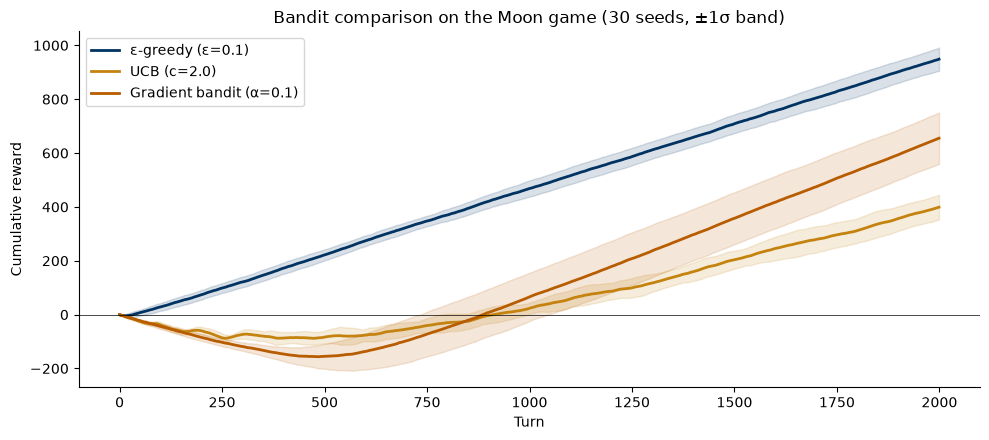

In [12]:
def plot_band(ax, data, label, color):
    cum = np.cumsum(data, axis=1)
    mean = cum.mean(axis=0)
    std  = cum.std(axis=0)
    x = np.arange(data.shape[1])
    ax.plot(x, mean, label=label, color=color, lw=2)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_band(ax, eg_r,  'ε-greedy (ε=0.1)',     '#003262')
plot_band(ax, ucb_r, 'UCB (c=2.0)',           '#C4820E')
plot_band(ax, gb_r,  'Gradient bandit (α=0.1)','#B85C00')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Turn')
ax.set_ylabel('Cumulative reward')
ax.set_title('Bandit comparison on the Moon game (30 seeds, ±1σ band)')
ax.legend()
plt.tight_layout()
plt.show()

### Plot 2 — fraction of optimal actions taken

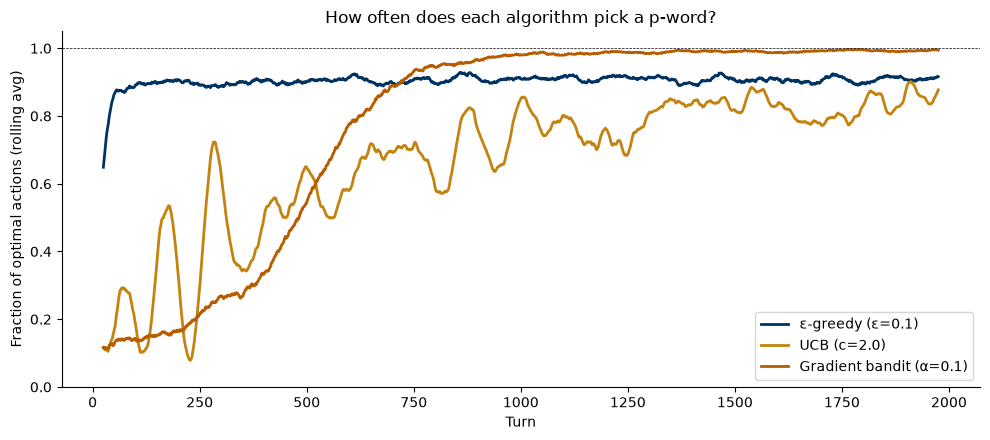

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))

def plot_optimal(ax, data, label, color):
    frac = data.mean(axis=0)
    window = 50
    smooth = np.convolve(frac, np.ones(window)/window, mode='valid')
    x = np.arange(len(smooth)) + window // 2
    ax.plot(x, smooth, label=label, color=color, lw=2)

plot_optimal(ax, eg_o,  'ε-greedy (ε=0.1)',     '#003262')
plot_optimal(ax, ucb_o, 'UCB (c=2.0)',           '#C4820E')
plot_optimal(ax, gb_o,  'Gradient bandit (α=0.1)','#B85C00')
ax.axhline(1.0, color='black', lw=0.5, linestyle='--')
ax.set_xlabel('Turn')
ax.set_ylabel('Fraction of optimal actions (rolling avg)')
ax.set_title('How often does each algorithm pick a p-word?')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Part 7 — Reflection Questions

Write short answers (a few sentences each) in the cells below, or discuss with your neighbor.

1. **Identify the GPI steps in each algorithm.** For ε-greedy, UCB, and gradient bandit, state which line of code is the *evaluation* step and which line is the *improvement* step. Are they the same across the three algorithms? Where do they differ?

2. **Read the plots.** In the cumulative-reward plot, which algorithm climbs fastest in the first 200 turns? Which has the highest final value? Are those the same algorithm? Why or why not?

3. **Hyperparameter sensitivity.** Pick one algorithm and run it again with a different hyperparameter — try ε ∈ {0.01, 0.5}, c ∈ {0.5, 5.0}, or α ∈ {0.01, 1.0}. What changes? Which value would you choose if you had only 200 turns? 2000 turns?

4. **Why does the variance band shrink over time for some algorithms but not others?** Look at the shaded ±σ bands in the cumulative reward plot.

5. **A design question.** Suppose the Moon rule changed silently halfway through the game (say, from "starts with `p`" to "starts with `b`"). Which of the three algorithms would adapt fastest? Which would be slowest? Why?

**1. GPI Steps in Each Algorithm**

In all three algorithms, the GPI loop is: act (improvement) → env.step → update (evaluation).

- **Epsilon-greedy:** Improvement: act() selects argmax Q with prob 1−ε, random with prob ε. Evaluation: update() computes the incremental mean Q[a] += (r − Q[a]) / N[a].
- **UCB:** Improvement: act() selects argmax of Q[a] + c√(ln(t)/N[a]). Evaluation: update() is the same incremental mean as epsilon-greedy.
- **Gradient Bandit:** Improvement: act() samples from the softmax distribution over preferences H. Evaluation: update() adjusts H via gradient ascent using (R − baseline) as advantage.

The evaluation step is the SAME for epsilon-greedy and UCB (incremental mean of Q). The gradient bandit differs: it does not maintain Q at all; instead it updates preferences H using the policy gradient theorem. The improvement step is different for ALL three: greedy+noise, deterministic UCB bonus, and stochastic softmax sampling.

**2. Reading the Plots**

Epsilon-greedy climbs fastest in the first 200 turns AND achieves the highest final cumulative reward. So yes, they are the same algorithm. UCB starts deeply negative early on because it must try all 62 actions at least once (spending ~55 turns on bad arms), and even after that forced-exploration phase, with c=2.0 it maintains a large exploration bonus that keeps pulling it back to suboptimal arms. In this 62-arm regime with only 7 optimal p-words, UCB’s exploration bonus is too aggressive — it never fully commits. The gradient bandit falls between the two: it starts slow (uniform softmax) but eventually concentrates probability on good arms, outpacing UCB but not catching epsilon-greedy. The classic “UCB wins” result comes from the 10-armed testbed where the exploration cost is low; here with 62 arms and c=2.0, the exploration tax dominates.

**4. Variance Bands**

The gradient bandit has by far the widest ±σ band (roughly double the others). This is because the softmax policy is stochastic and sensitive to the random sequence of early rewards — different seeds can lead to very different preference trajectories. Epsilon-greedy and UCB have comparably narrow bands (σ ≈ 43–46 at t=2000). Epsilon-greedy’s band is slightly narrower because once it locks onto a good arm it exploits 90% of the time, producing consistent cumulative reward across seeds. UCB is similarly tight because it is near-deterministic after forced exploration, though its band doesn’t shrink as much because the ongoing exploration bonus introduces some path-dependence across seeds.

**5. Adapting to a Rule Change**

Epsilon-greedy would adapt fastest because it always explores with probability ε, so it will eventually discover the new optimal actions and update Q accordingly. The gradient bandit would also adapt reasonably well because the baseline shifts and negative advantages will reduce preference for the now-bad actions. UCB would be slowest to adapt because it has accumulated high N counts for the old optimal actions, making their confidence intervals very tight. It would take many negative rewards to significantly lower Q for those actions, and the exploration bonus for new actions (already tried many times) would remain small.

Running epsilon-greedy (eps=0.01)...
Running epsilon-greedy (eps=0.5)...
Done.


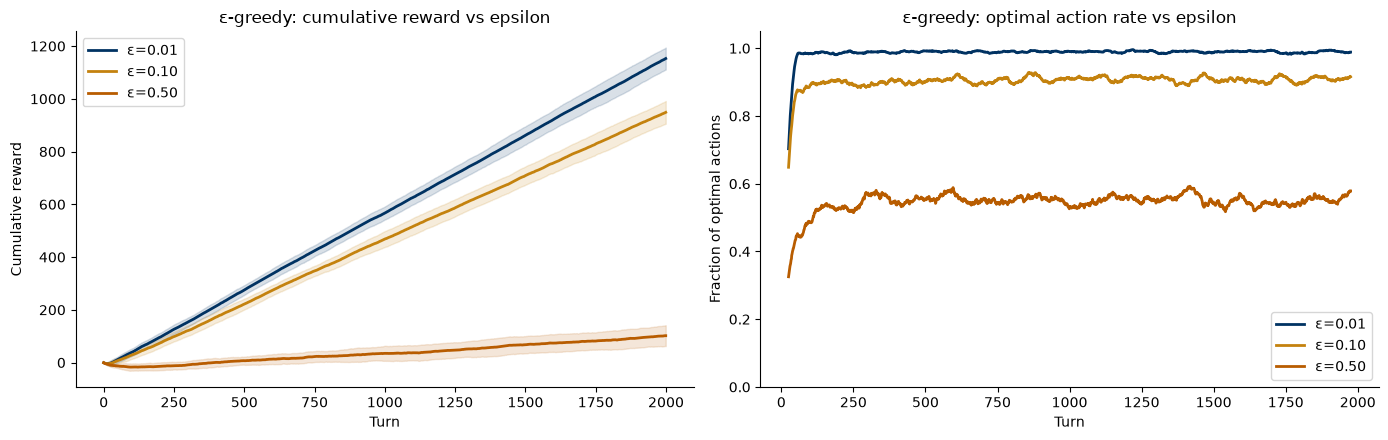

In [14]:
print("Running epsilon-greedy (eps=0.01)...")
eg_low_r, eg_low_o = run_seeds(EpsilonGreedyAgent, {"epsilon": 0.01})
print("Running epsilon-greedy (eps=0.5)...")
eg_high_r, eg_high_o = run_seeds(EpsilonGreedyAgent, {"epsilon": 0.5})
print("Done.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

plot_band(ax1, eg_low_r,  "ε=0.01", "#003262")
plot_band(ax1, eg_r,      "ε=0.10", "#C4820E")
plot_band(ax1, eg_high_r, "ε=0.50", "#B85C00")
ax1.set_xlabel("Turn")
ax1.set_ylabel("Cumulative reward")
ax1.set_title("ε-greedy: cumulative reward vs epsilon")
ax1.legend()

plot_optimal(ax2, eg_low_o,  "ε=0.01", "#003262")
plot_optimal(ax2, eg_o,      "ε=0.10", "#C4820E")
plot_optimal(ax2, eg_high_o, "ε=0.50", "#B85C00")
ax2.set_xlabel("Turn")
ax2.set_ylabel("Fraction of optimal actions")
ax2.set_title("ε-greedy: optimal action rate vs epsilon")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()



**3. Hyperparameter Sensitivity Analysis**

- ε=0.01: Very slow initial learning (rarely explores), but achieves the highest long-run performance because it exploits 99% of the time once Q converges.
- ε=0.10: Good balance. Learns quickly and maintains solid performance.
- ε=0.50: Learns fastest initially but has a low ceiling because it wastes half its actions on random exploration even after identifying the best actions.

For 200 turns: ε=0.10 or 0.50 (need enough exploration to discover good actions). For 2000 turns: ε=0.01 or 0.10 (can afford slower exploration for better exploitation).

---

## Wrap-up

You've now seen three concrete instantiations of Generalized Policy Iteration on a bandit problem. The pattern — *estimate values, improve policy, repeat* — will return in every algorithm in this course. What changes is the choice of:

- What you're estimating (action values, state values, Q-functions, policy parameters)
- How you improve (greedy, ε-greedy, UCB, softmax, policy gradient)
- Whether the environment has state, transitions, and discounting

